**Kaggle Kernel Config:**

In [7]:
# KAGGLE_CONFIG: execute = true
# KAGGLE_CONFIG: slug = "notebool-consuming-cpu"
# KAGGLE_CONFIG: language = "python"
# KAGGLE_CONFIG: kernel_type = "notebook"
# KAGGLE_CONFIG: is_private = false
# KAGGLE_CONFIG: enable_gpu = false
# KAGGLE_CONFIG: enable_tpu = false
# KAGGLE_CONFIG: enable_internet = false
# KAGGLE_CONFIG: machine_shape = ""
# KAGGLE_CONFIG: dataset_sources = []
# KAGGLE_CONFIG: competition_sources = []
# KAGGLE_CONFIG: kernel_sources = []
# KAGGLE_CONFIG: model_sources = []
# KAGGLE_CONFIG: keywords = ["classification"]

In [9]:
from datetime import datetime, timezone
print('executed at:',datetime.now(timezone.utc).isoformat())

executed at: 2026-08-13T13:53:30.109374+00:00


# Notebook Consuming : CPU

## Importing Libraries

In [1]:
import os
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 1. Load Dataset

In [3]:
print("Loading Breast Cancer dataset...")
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Split dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Loading Breast Cancer dataset...


## 2. Train Model

In [4]:
print("Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

Training Random Forest Classifier...


RandomForestClassifier(random_state=42)

## 3. Model Evaluation


Model Accuracy: 95.61%

--- Classification Report ---
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--- Confusion Matrix (Raw Values) ---
[[39  3]
 [ 2 70]]


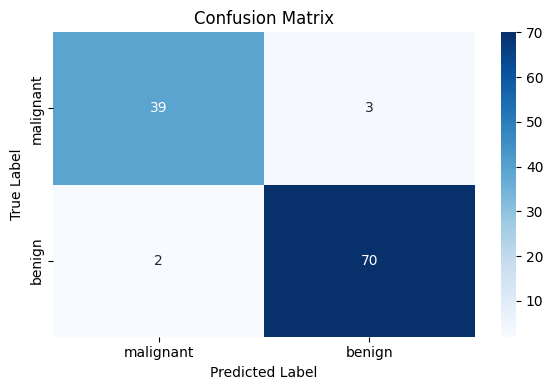

In [5]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\n" + "=" * 50)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("=" * 50)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Print Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix (Raw Values) ---")
print(cm)

# Display Confusion Matrix Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=data.target_names, 
    yticklabels=data.target_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 4. Save Artifact to Kaggle Working Directory

In [6]:
kaggle_output_dir = "/kaggle/working" if os.path.exists("/kaggle") else "./output"
os.makedirs(kaggle_output_dir, exist_ok=True)

model_path = os.path.join(kaggle_output_dir, "classifier_model.joblib")
joblib.dump(model, model_path)

print(f"\n✅ Model successfully saved to: {model_path}")


✅ Model successfully saved to: ./output/classifier_model.joblib
